# 1. Import modules 
In this section, the necessary Python libraries for data manipulation, visualization, and machine learning are imported.

- **Pandas and NumPy** are used for data handling and numerical operations.
- **Matplotlib and Seaborn** are used for data visualization.
- **Scikit-learn** provides tools for model building, evaluation, and hyperparameter tuning.

These libraries form the foundation for building and evaluating the machine learning model.

In [ ]:
# Import necessary libraries
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning 
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    log_loss
)

# 2. Load dataset and basic cleaning

The dataset was loaded using the Pandas library from a local directory. Initial inspection was performed by displaying the first few rows of the dataset to understand its structure and contents.

To improve consistency and ease of use, column names were cleaned by removing whitespace, converting them to lowercase, and replacing spaces with underscores. This ensures uniform naming conventions throughout the analysis.

Basic inspection of the dataset was also conducted to examine its dimensions, data types, and potential missing values.

In [101]:
#Load dataset
df = pd.read_csv("../Dataset/Breast_Cancer.csv")

#Show first 5 rows
df.head()

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive


In [78]:
df.shape

(4024, 16)

In [102]:
# Clean column names
df.columns = df.columns.str.strip().str.replace(' ', '_').str.lower()

df.head()


,age,race,marital_status,t_stage,n_stage,6th_stage,differentiate,grade,a_stage,tumor_size,estrogen_status,progesterone_status,regional_node_examined,reginol_node_positive,survival_months,status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive


# 3. Data Exploration

In this section, exploratory data analysis (EDA) was conducted to understand the structure and characteristics of the dataset.

The dataset was examined in terms of its dimensions, feature types, and statistical properties. The summary statistics provide insights into the distribution of numerical features such as age, tumor size, and survival months.

Additionally, missing values were checked to ensure data quality. No missing values were found, indicating that the dataset is clean and suitable for further analysis.

The distribution of the target variable (status) was also analyzed to assess class balance. This is important for understanding potential bias in model predictions.

In [103]:
# Check dataset shape
df.shape

# Column names
df.columns

# Data types and missing values
df.info()

# Statistical summary
df.describe()

# Missing values
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   age                     4024 non-null   int64
 1   race                    4024 non-null   str  
 2   marital_status          4024 non-null   str  
 3   t_stage                 4024 non-null   str  
 4   n_stage                 4024 non-null   str  
 5   6th_stage               4024 non-null   str  
 6   differentiate           4024 non-null   str  
 7   grade                   4024 non-null   str  
 8   a_stage                 4024 non-null   str  
 9   tumor_size              4024 non-null   int64
 10  estrogen_status         4024 non-null   str  
 11  progesterone_status     4024 non-null   str  
 12  regional_node_examined  4024 non-null   int64
 13  reginol_node_positive   4024 non-null   int64
 14  survival_months         4024 non-null   int64
 15  status                  4024 non

age                       0
race                      0
marital_status            0
t_stage                   0
n_stage                   0
6th_stage                 0
differentiate             0
grade                     0
a_stage                   0
tumor_size                0
estrogen_status           0
progesterone_status       0
regional_node_examined    0
reginol_node_positive     0
survival_months           0
status                    0
dtype: int64

In [104]:
# Target variable distribution
df["status"].value_counts()

status
Alive    3408
Dead      616
Name: count, dtype: int64

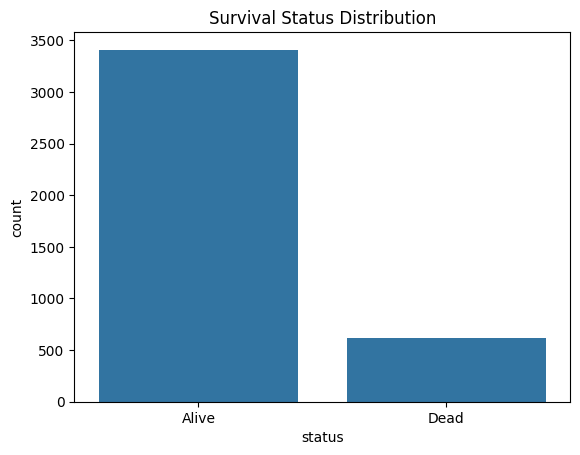

In [105]:
sns.countplot(x=df["status"])
plt.title("Survival Status Distribution")
plt.show()

# 4. Feature Engineering

Feature engineering was performed to enhance the predictive power of the model by creating new features from existing variables.

Two new features were introduced:

- **Node Ratio**: Represents the proportion of positive lymph nodes relative to the total number of examined nodes. This may provide insight into disease severity.
- **Tumor Size to Age Ratio**: Normalizes tumor size with respect to patient age, capturing relative impact.

These engineered features aim to capture underlying relationships in the data that may not be directly evident from the original features.

In [ ]:
#Encoding target variable 
df["status"] = df["status"].map({"Alive": 1, "Dead": 0}) 
# This is usually done after feature engineering, but in here it's done before because encoded values will be used for correlation mapping

In [108]:
df["status"] = df["status"].astype(int)

In [112]:
df["status"].value_counts()
df["status"].isnull().sum()


np.int64(0)

In [110]:
# Ratio of positive nodes to examined nodes
df["node_ratio"] = df["reginol_node_positive"] / (df["regional_node_examined"] + 1)

# Tumor size relative to age
df["tumor_size_age_ratio"] = df["tumor_size"] / (df["age"] + 1)

df.head()

,age,race,marital_status,t_stage,n_stage,6th_stage,differentiate,grade,a_stage,tumor_size,estrogen_status,progesterone_status,regional_node_examined,reginol_node_positive,survival_months,status,node_ratio,tumor_size_age_ratio
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,1,0.040000,0.057971
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,1,0.333333,0.686275
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,1,0.466667,1.067797
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,1,0.333333,0.305085
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,1,0.250000,0.854167


In [111]:
# Check correlation of new features
df[["node_ratio", "tumor_size_age_ratio", "status"]].corr()

,node_ratio,tumor_size_age_ratio,status
node_ratio,1.000000,0.229863,-0.270696
tumor_size_age_ratio,0.229863,1.000000,-0.120598
status,-0.270696,-0.120598,1.000000


# 5. Data Preprocessing

In this step, the dataset was prepared for machine learning by transforming categorical variables into a numerical format.

First, categorical features such as race, marital status, and cancer stage were identified. These features cannot be directly used by machine learning algorithms, as they require numerical inputs.

To address this, one-hot encoding was applied to convert categorical variables into binary indicator variables. The parameter `drop_first=True` was used to avoid multicollinearity by removing one redundant category from each encoded feature.

The dataset was then split into input features (X) and the target variable (y), where the target represents patient survival status.

This preprocessing ensures that the dataset is in a suitable format for training machine learning models.

In [118]:
#Identify categorical columns
cat_cols = df.select_dtypes(include=["object", "string"]).columns

In [119]:
# Apply one-hot encoding to categorical features
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

df_encoded.head()

,age,tumor_size,regional_node_examined,reginol_node_positive,survival_months,status,node_ratio,tumor_size_age_ratio,race_Other,race_White,...,6th_stage_IIIC,differentiate_Poorly differentiated,differentiate_Undifferentiated,differentiate_Well differentiated,grade_1,grade_2,grade_3,a_stage_Regional,estrogen_status_Positive,progesterone_status_Positive
0,68,4,24,1,60,1,0.040000,0.057971,False,True,...,False,True,False,False,False,False,True,True,True,True
1,50,35,14,5,62,1,0.333333,0.686275,False,True,...,False,False,False,False,False,True,False,True,True,True
2,58,63,14,7,75,1,0.466667,1.067797,False,True,...,True,False,False,False,False,True,False,True,True,True
3,58,18,2,1,84,1,0.333333,0.305085,False,True,...,False,True,False,False,False,False,True,True,True,True
4,47,41,3,1,50,1,0.250000,0.854167,False,True,...,False,True,False,False,False,False,True,True,True,True


In [120]:
# Separate features and target
X = df_encoded.drop("status", axis=1)
y = df_encoded["status"]

# Check shapes
X.shape, y.shape

((4024, 31), (4024,))

In [121]:
# Check for class balance
y.value_counts(normalize=True)

status
1    0.846918
0    0.153082
Name: proportion, dtype: float64

# Train/Test data split

In [125]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   
)

# Check sizes
X_train.shape, X_test.shape

((3219, 31), (805, 31))

In [126]:
y_train.value_counts(normalize=True)
y_test.value_counts(normalize=True)

status
1    0.847205
0    0.152795
Name: proportion, dtype: float64

# Model Building

In [122]:
from sklearn.ensemble import RandomForestClassifier

# Baseline model (retrain)
rf_base = RandomForestClassifier(n_estimators=100, random_state=42)
rf_base.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [123]:
from sklearn.ensemble import RandomForestClassifier

# Manually tuned model
rf_tuned = RandomForestClassifier(
    n_estimators=200,        # more trees → better stability
    max_depth=10,            # limit depth → reduce overfitting
    min_samples_split=5,     # avoid too many splits
    min_samples_leaf=2,      # ensure leaf nodes have enough data
    max_features='sqrt',     # common good practice
    random_state=42
)

# Train model
rf_tuned.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

# Hyper-parameter tunning 

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# Initialize model
rf = RandomForestClassifier(random_state=42)

# GridSearch
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    n_jobs=-1,
    verbose=2
)

# Fit
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candida

In [ ]:
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}


In [ ]:
best_rf = grid_search.best_estimator_

# Train (already fitted, but safe practice)
best_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

# Parameter distribution
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,        # number of combinations to try
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

# Model Evaluation

In [ ]:
from sklearn.metrics import accuracy_score

# Baseline
y_pred_base = rf_base.predict(X_test)

# Manual tuned
y_pred_tuned = rf_tuned.predict(X_test)

# GridSearch best
y_pred_best = best_rf.predict(X_test)

print("Baseline Accuracy:", accuracy_score(y_test, y_pred_base))
print("Manual Tuned Accuracy:", accuracy_score(y_test, y_pred_tuned))
print("GridSearch Best Accuracy:", accuracy_score(y_test, y_pred_best))

Baseline Accuracy: 0.9118012422360249
Manual Tuned Accuracy: 0.9192546583850931
GridSearch Best Accuracy: 0.9192546583850931


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    log_loss
)

# Use best model (or compare all)
y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("\nROC-AUC Score:", roc_auc_score(y_test, y_prob))
print("Log Loss (Cross-Entropy):", log_loss(y_test, y_prob))

Accuracy: 0.9192546583850931

Confusion Matrix:
 [[ 61  59]
 [  6 679]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.51      0.65       120
           1       0.92      0.99      0.95       685

    accuracy                           0.92       805
   macro avg       0.92      0.75      0.80       805
weighted avg       0.92      0.92      0.91       805


ROC-AUC Score: 0.8911435523114355
Log Loss (Cross-Entropy): 0.25377866589398124


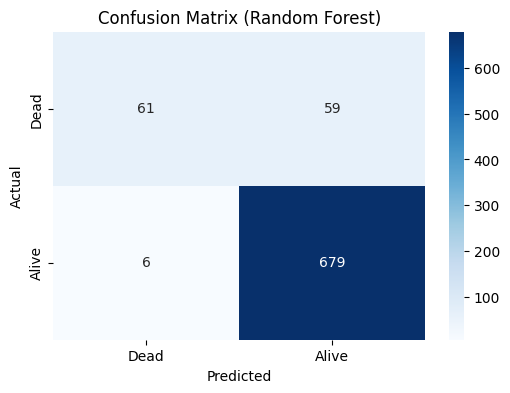

In [ ]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

# Plot
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Dead", "Alive"],
            yticklabels=["Dead", "Alive"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Random Forest)")
plt.show()

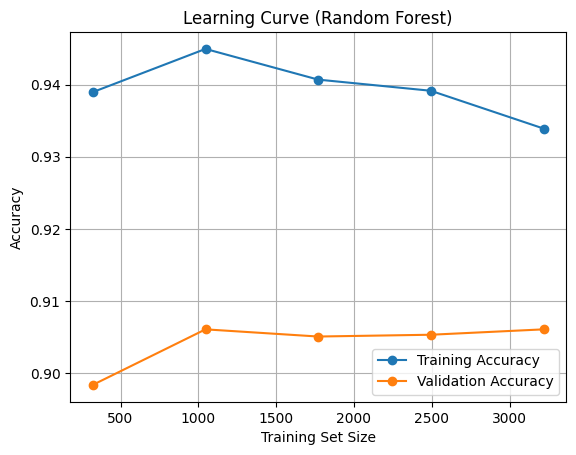

In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np


train_sizes, train_scores, test_scores = learning_curve(
    best_rf, X, y,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5),
    n_jobs=-1
)

# Mean scores
train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

# Plot
plt.plot(train_sizes, train_mean, label="Training Accuracy", marker='o')
plt.plot(train_sizes, test_mean, label="Validation Accuracy", marker='o')

plt.title("Learning Curve (Random Forest)")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

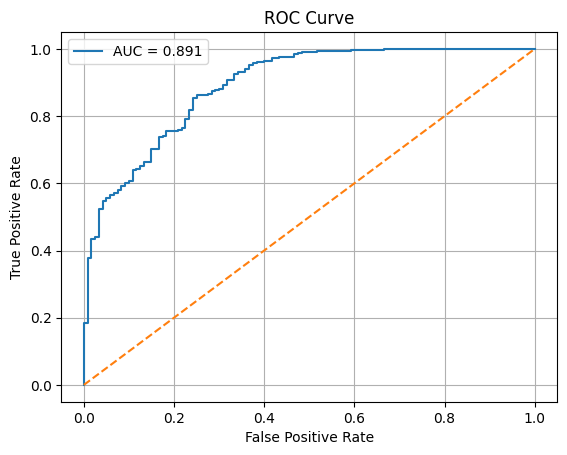

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
# Probabilities
y_prob = best_rf.predict_proba(X_test)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

# Plot
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')  # random line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

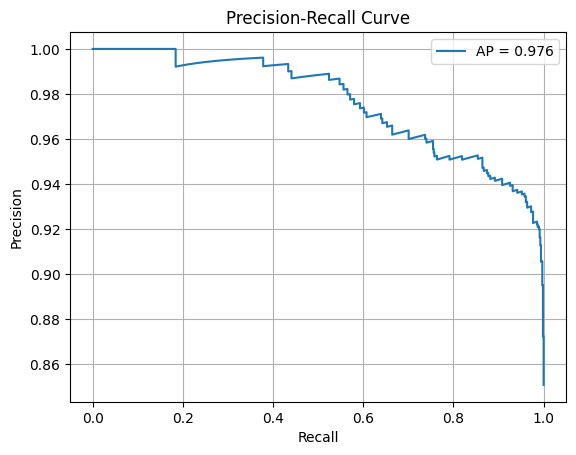

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Precision-Recall values
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
ap_score = average_precision_score(y_test, y_prob)

# Plot
plt.plot(recall, precision, label=f"AP = {ap_score:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid()
plt.show()

# Feature Importance

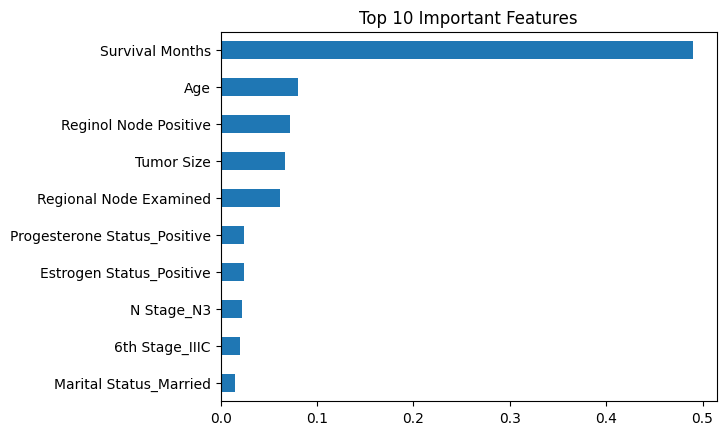

In [ ]:
import matplotlib.pyplot as plt

# Get feature importance
importances = best_rf.feature_importances_
features = X.columns

# Create series
feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

# Plot top 10
feat_imp.head(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()
plt.show()

# Analysis

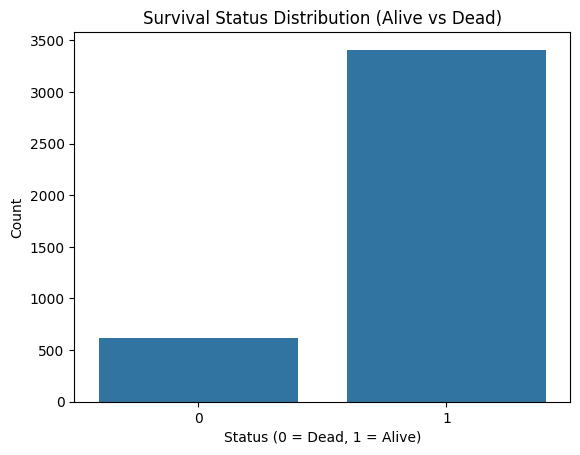

In [ ]:
sns.countplot(x=y)
plt.title("Survival Status Distribution (Alive vs Dead)")
plt.xlabel("Status (0 = Dead, 1 = Alive)")
plt.ylabel("Count")
plt.show()

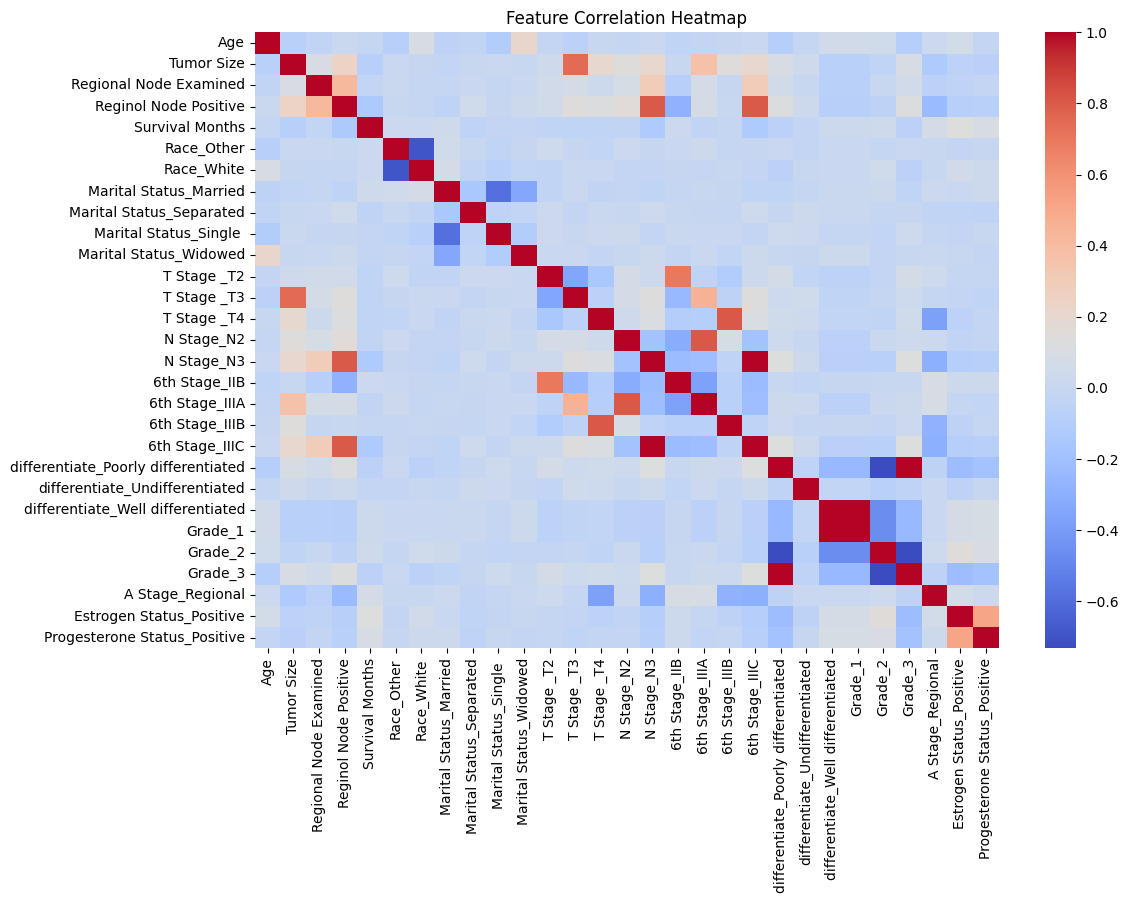

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(X.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

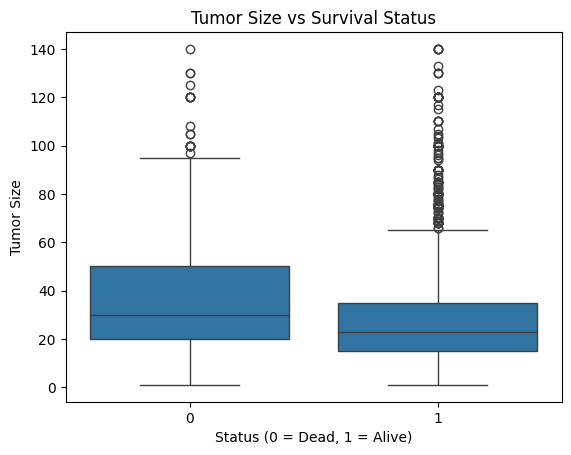

In [ ]:
sns.boxplot(x=y, y=X["Tumor Size"])
plt.title("Tumor Size vs Survival Status")
plt.xlabel("Status (0 = Dead, 1 = Alive)")
plt.ylabel("Tumor Size")
plt.show()

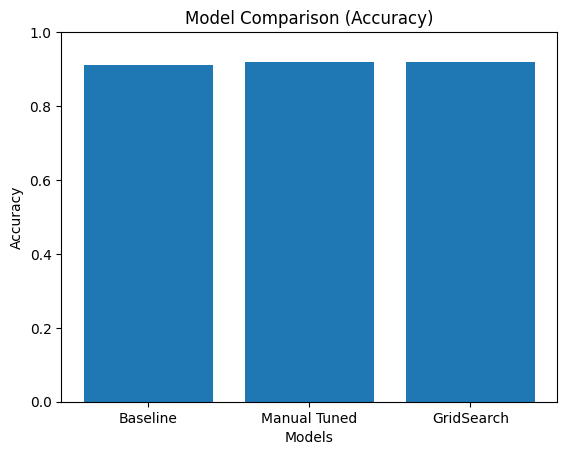

In [ ]:
import matplotlib.pyplot as plt

# Accuracies (replace with your actual values)
models = ["Baseline", "Manual Tuned", "GridSearch"]
accuracies = [
    accuracy_score(y_test, y_pred_base),
    accuracy_score(y_test, y_pred_tuned),
    accuracy_score(y_test, y_pred_best)
]

plt.bar(models, accuracies)
plt.title("Model Comparison (Accuracy)")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()